In [126]:
import pandas as pd
import numpy as np

In [127]:
df=pd.read_csv('/content/Titanic Dataset.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [128]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [129]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [130]:
df['Cabin']=df['Cabin'].fillna('Unknown')
df['Embarked']=df['Embarked'].fillna(df['Embarked'].mode()[0])
# df['Age']=df['Age'].fillna(df['Age'].mean())

In [131]:
import matplotlib.pyplot as plt
import seaborn as sns

<Axes: ylabel='Age'>

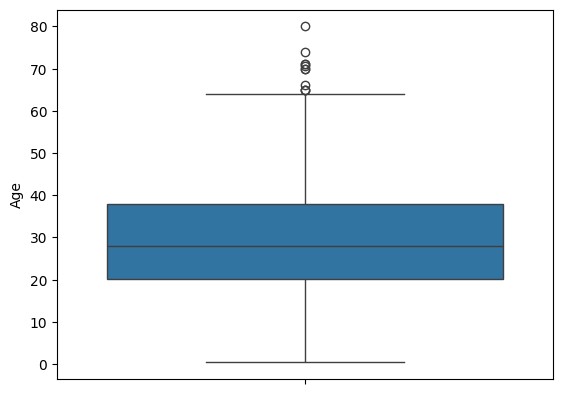

In [132]:
sns.boxplot(df['Age'])

(array([ 54.,  46., 177., 169., 118.,  70.,  45.,  24.,   9.,   2.]),
 array([ 0.42 ,  8.378, 16.336, 24.294, 32.252, 40.21 , 48.168, 56.126,
        64.084, 72.042, 80.   ]),
 <BarContainer object of 10 artists>)

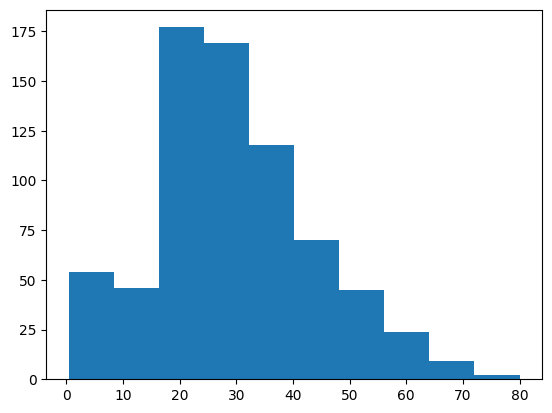

In [133]:
plt.hist(df.Age)

In [134]:
df['Age'].describe()

,Age
count,714.000000
mean,29.699118
std,14.526497
min,0.420000
25%,20.125000
50%,28.000000
75%,38.000000
max,80.000000


In [135]:
dfage=df.groupby(['Age']).count()
dfage

,PassengerId,Survived,Pclass,Name,Sex,SibSp,Parch,Ticket,Fare,Cabin,Embarked
Age,,,,,,,,,,,
0.42,1,1,1,1,1,1,1,1,1,1,1
0.67,1,1,1,1,1,1,1,1,1,1,1
0.75,2,2,2,2,2,2,2,2,2,2,2
0.83,2,2,2,2,2,2,2,2,2,2,2
0.92,1,1,1,1,1,1,1,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...
70.00,2,2,2,2,2,2,2,2,2,2,2
70.50,1,1,1,1,1,1,1,1,1,1,1
71.00,2,2,2,2,2,2,2,2,2,2,2


In [136]:
df['Age']=df['Age'].mask(df["Age"]>60,60)
# df['Age']=df['Age'].mask(df["Age"]<1,1)

In [137]:
df['Age']=df['Age'].fillna(df['Age'].mean())

<Axes: ylabel='Age'>

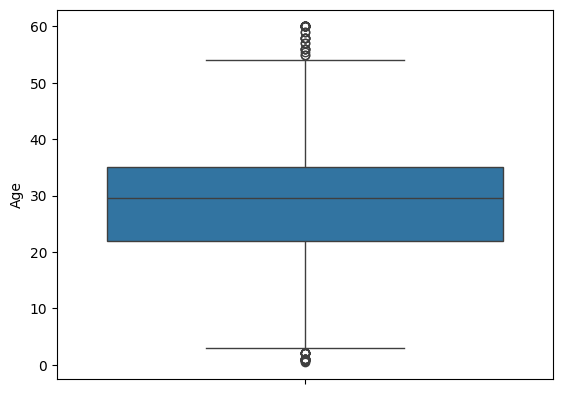

In [138]:
sns.boxplot(df['Age'])

(array([ 47.,  22.,  70., 138., 309., 110.,  66.,  49.,  38.,  42.]),
 array([ 0.42 ,  6.378, 12.336, 18.294, 24.252, 30.21 , 36.168, 42.126,
        48.084, 54.042, 60.   ]),
 <BarContainer object of 10 artists>)

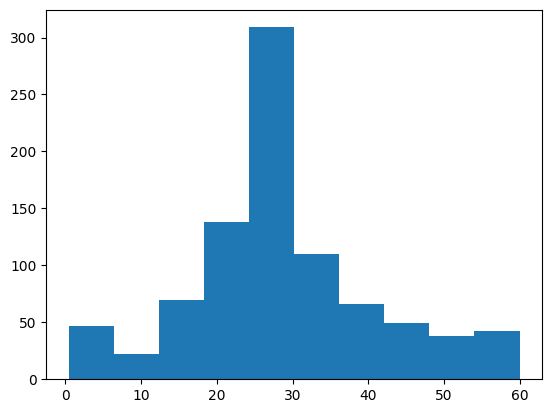

In [139]:
plt.hist(df.Age)

In [140]:
df['Sex']=df['Sex'].map({'male':1,'female':0})

In [ ]:
# df['Pclass']=df['Pclass'].map({1:'F',2:'S',3:'T'})

In [141]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    int64  
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        891 non-null    object 
 11  Embarked     891 non-null    object 
dtypes: float64(2), int64(6), object(4)
memory usage: 83.7+ KB


In [142]:
df.groupby(['Sex','Survived']).count()

PassengerId  Pclass  Name  Age  SibSp  Parch  Ticket  Fare  \
Sex Survived                                                               
0   0                  81      81    81   81     81     81      81    81   
    1                 233     233   233  233    233    233     233   233   
1   0                 468     468   468  468    468    468     468   468   
    1                 109     109   109  109    109    109     109   109   

              Cabin  Embarked  
Sex Survived                   
0   0            81        81  
    1           233       233  
1   0           468       468  
    1           109       109

In [143]:
df1=df.drop(['PassengerId','Name','Ticket','Cabin','Embarked'],axis=1)

In [144]:
df1 = pd.get_dummies(df1, dtype=int)
df1.head(10)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare
0,0,3,1,22.000000,1,0,7.2500
1,1,1,0,38.000000,1,0,71.2833
2,1,3,0,26.000000,0,0,7.9250
3,1,1,0,35.000000,1,0,53.1000
4,0,3,1,35.000000,0,0,8.0500
5,0,3,1,29.513543,0,0,8.4583
6,0,1,1,54.000000,0,0,51.8625
7,0,3,1,2.000000,3,1,21.0750
8,1,3,0,27.000000,0,2,11.1333
9,1,2,0,14.000000,1,0,30.0708


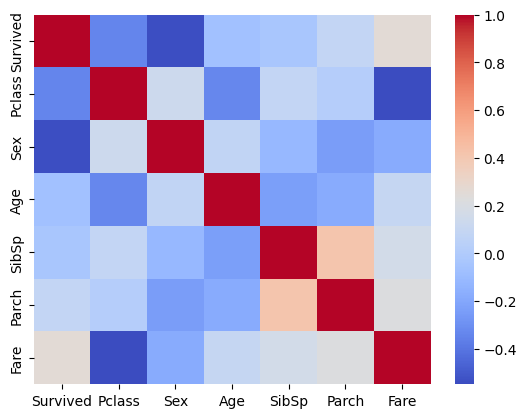

In [145]:
sns.heatmap(df1.corr(),
            cmap='coolwarm')
plt.show()

In [146]:
X=df1.drop('Survived',axis=1)
y=df1['Survived']

In [147]:
from sklearn.model_selection import train_test_split as tts
X_train, X_test, y_train, y_test=tts(X,y,test_size=0.2,random_state=42)

In [148]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()
model.fit(X_train,y_train)

LogisticRegression()

In [149]:
y_pred=model.predict(X_test)
y_pred

array([0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0,
       0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0,
       0, 1, 1])

In [150]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test,y_pred)

array([[92, 13],
       [20, 54]])

In [151]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.8156424581005587